<h2>Background and introducing the problem:</h2>
<body>
<p>This dataset contains 1,000 observational records of earthquakes, spanning the period from 1995 to 2023. This dataset also includes 19 variables related to earthquakes. With this dataset, my goal is to use statistical analysis of an earthquake to measure which factors influence the alert levels of an earthquake: </p>
    <ul>
      <li>Magnitude</li>
      <li>Maximum reported intensity (cdi)</li>
      <li>Maximum estimated intensity (mmi)</li>
      <li>Significance of event (sig)</li>
      <li>tsunami </li>
      <li>depth </li>
    </ul>  
</body>


<h2>Loading in the data:</h2>

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

eq_data = pd.read_csv("earthquake_1995-2023.csv")
eq_data.head(3)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina


<h2>Looking at the data:</h2>

In [112]:
eq_data.isna().sum()

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        551
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       6
continent    716
country      349
dtype: int64

<p>Since content and country have missing values, we will start by taking out these values as they do not pertain to the goal of the statistical learning. Furthermore, we will also discard the value of date_time, location, and title, as they do not pertain to the ultimate goal.</p>

<h2>Cleaning the data:</h2>
<body>
    <p>For cleaning the data, we removed the data that had inconsistencies or missing values. Keeping only those factors that will be used, and discarding the ones that will not be used. Ensuring that the data is organized and concise.</p>
    <p><b>Data removed:</b><p>
    <ul>
      <li>title</li>
      <li>date_time</li>
      <li>net</li>
      <li>nst</li>
      <li>dmin</li>
      <li>gap</li>
      <li>latitude</li>
      <li>longitude</li>
      <li>location</li>
      <li>continent</li>
      <li>country</li>
      <li>magType</li>
    </ul>
    <p>Only keeping magnitude, cdi, mmi, alert, tsunami,  sig, and depth as they strongly affect the alert being as they are numerical and more scientifically related to the earthquake records. We also eliminated any missing values.</p>
</body>


In [193]:
new_data = eq_data.dropna()
new_eq_data = new_data.drop(['title','date_time', 'net', 'nst','dmin','gap','latitude','longitude','location','country', 'continent', 'magType'], axis = 1)
new_eq_data

,magnitude,cdi,mmi,alert,tsunami,sig,depth
2,6.6,7,5,green,0,899,171.371
17,6.5,7,6,yellow,1,655,105.631
18,7.0,7,7,green,1,781,62.603
19,6.5,4,4,green,0,656,209.976
20,6.5,7,5,green,0,1350,187.589
...,...,...,...,...,...,...,...
441,6.6,0,7,green,1,670,11.000
443,6.9,5,5,green,1,904,145.000
450,6.9,6,7,yellow,0,814,107.000
451,6.8,6,7,green,0,771,45.000


<h2>Wrangling and munging the data:</h2>
<body>
    <p>To make the data more organized, concise, and readable, we renamed some variables:</p>
    <ul>
        <li>cdi -> max_rep_intensity</li>
        <li>mmi -> max_est_intensity</li>
        <li>alert -> alert_level</li>
        <li>sig -> significance</li>
    </ul>
</body>

In [198]:
new_eq_data.rename(columns={'cdi': 'max_rep_intensity', 'mmi': 'max_est_intensity', 'alert': 'alert_level', 'sig':'significance'}, inplace = True)
new_eq_data

,magnitude,max_rep_intensity,max_est_intensity,alert_level,tsunami,significance,depth
2,6.6,7,5,green,0,899,171.371
17,6.5,7,6,yellow,1,655,105.631
18,7.0,7,7,green,1,781,62.603
19,6.5,4,4,green,0,656,209.976
20,6.5,7,5,green,0,1350,187.589
...,...,...,...,...,...,...,...
441,6.6,0,7,green,1,670,11.000
443,6.9,5,5,green,1,904,145.000
450,6.9,6,7,yellow,0,814,107.000
451,6.8,6,7,green,0,771,45.000


<p>looking at the type of range of the alert levels:</p>

In [200]:
new_eq_data['alert_level'].unique()

array(['green', 'yellow', 'orange', 'red'], dtype=object)

<h2>We add alert codes to see the mean, std, and other factors that affect the alert level.</h2>
<body>
    <ul>
        <li>green -> 0</li>
        <li>yellow -> 1</li>
        <li>orange-> 2</li>
        <li>red -> 3</li>
    </ul>
</body>

In [203]:
new_eq_data['alert_code'], uniques = pd.factorize(new_eq_data['alert_level'])
new_eq_data


,magnitude,max_rep_intensity,max_est_intensity,alert_level,tsunami,significance,depth,alert_code
2,6.6,7,5,green,0,899,171.371,0
17,6.5,7,6,yellow,1,655,105.631,1
18,7.0,7,7,green,1,781,62.603,0
19,6.5,4,4,green,0,656,209.976,0
20,6.5,7,5,green,0,1350,187.589,0
...,...,...,...,...,...,...,...,...
441,6.6,0,7,green,1,670,11.000,0
443,6.9,5,5,green,1,904,145.000,0
450,6.9,6,7,yellow,0,814,107.000,1
451,6.8,6,7,green,0,771,45.000,0


<h2>Showing information:</h2>
<body>
    <p>We see that the mean is higher for significance and depth, showing the averages are high and the tsunami averages are low.</p>
</body>

In [205]:
new_eq_data.describe()

,magnitude,max_rep_intensity,max_est_intensity,tsunami,significance,depth,alert_code
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,6.956604,6.962264,6.830189,0.509434,1134.226415,100.901557,0.867925
std,0.388163,1.966019,1.558214,0.502286,547.858833,156.924924,1.014894
min,6.500000,0.000000,2.000000,0.000000,653.000000,2.700000,0.000000
25%,6.625000,6.000000,6.000000,0.000000,768.500000,14.326750,0.000000
50%,6.850000,8.000000,7.000000,1.000000,943.000000,31.839500,1.000000
75%,7.200000,8.000000,8.000000,1.000000,1342.500000,111.500000,2.000000
max,8.000000,9.000000,9.000000,1.000000,2910.000000,630.000000,3.000000


<p> Let's first take a look at the histogram of the total number of earthquakes and each alert level.</p>

<BarContainer object of 4 artists>

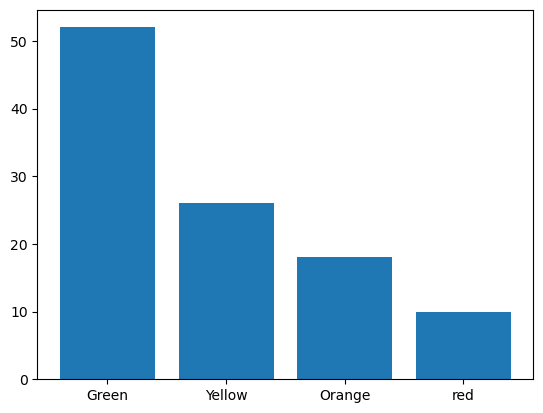

In [207]:
x_bar = ['Green', 'Yellow', 'Orange', 'red']
y_bar = [len(new_eq_data[new_eq_data['alert_level'] == 'green']), len(new_eq_data[new_eq_data['alert_level'] == 'yellow']), len(new_eq_data[new_eq_data['alert_level'] == 'orange']),
        len(new_eq_data[new_eq_data['alert_level'] == 'red'])]

plt.bar(x_bar, y_bar)

<h2>Using pearsons correlation coefficient:</h2>
<body>
    <p>We use Pearson's correlation coefficient to show how each factor is correlated to alert codes.</p>
</body>

In [209]:
new_eq_data[['magnitude', 'alert_code', 'tsunami', 'depth','max_rep_intensity', 'max_est_intensity','significance']].corr(method = 'pearson')

,magnitude,alert_code,tsunami,depth,max_rep_intensity,max_est_intensity,significance
magnitude,1.000000,0.323770,0.192627,0.019594,0.226215,0.305769,0.411563
alert_code,0.323770,1.000000,-0.165677,-0.356051,0.446152,0.605981,0.797441
tsunami,0.192627,-0.165677,1.000000,-0.126283,0.058230,0.062908,-0.130104
depth,0.019594,-0.356051,-0.126283,1.000000,-0.587310,-0.792876,-0.278838
max_rep_intensity,0.226215,0.446152,0.058230,-0.587310,1.000000,0.607217,0.434941
max_est_intensity,0.305769,0.605981,0.062908,-0.792876,0.607217,1.000000,0.532663
significance,0.411563,0.797441,-0.130104,-0.278838,0.434941,0.532663,1.000000


<h2>Showing Correlations:</h2>
<body>
    <p>We first make a plot showing the correlation of each factor of earthquake with each other.</p>
</body>

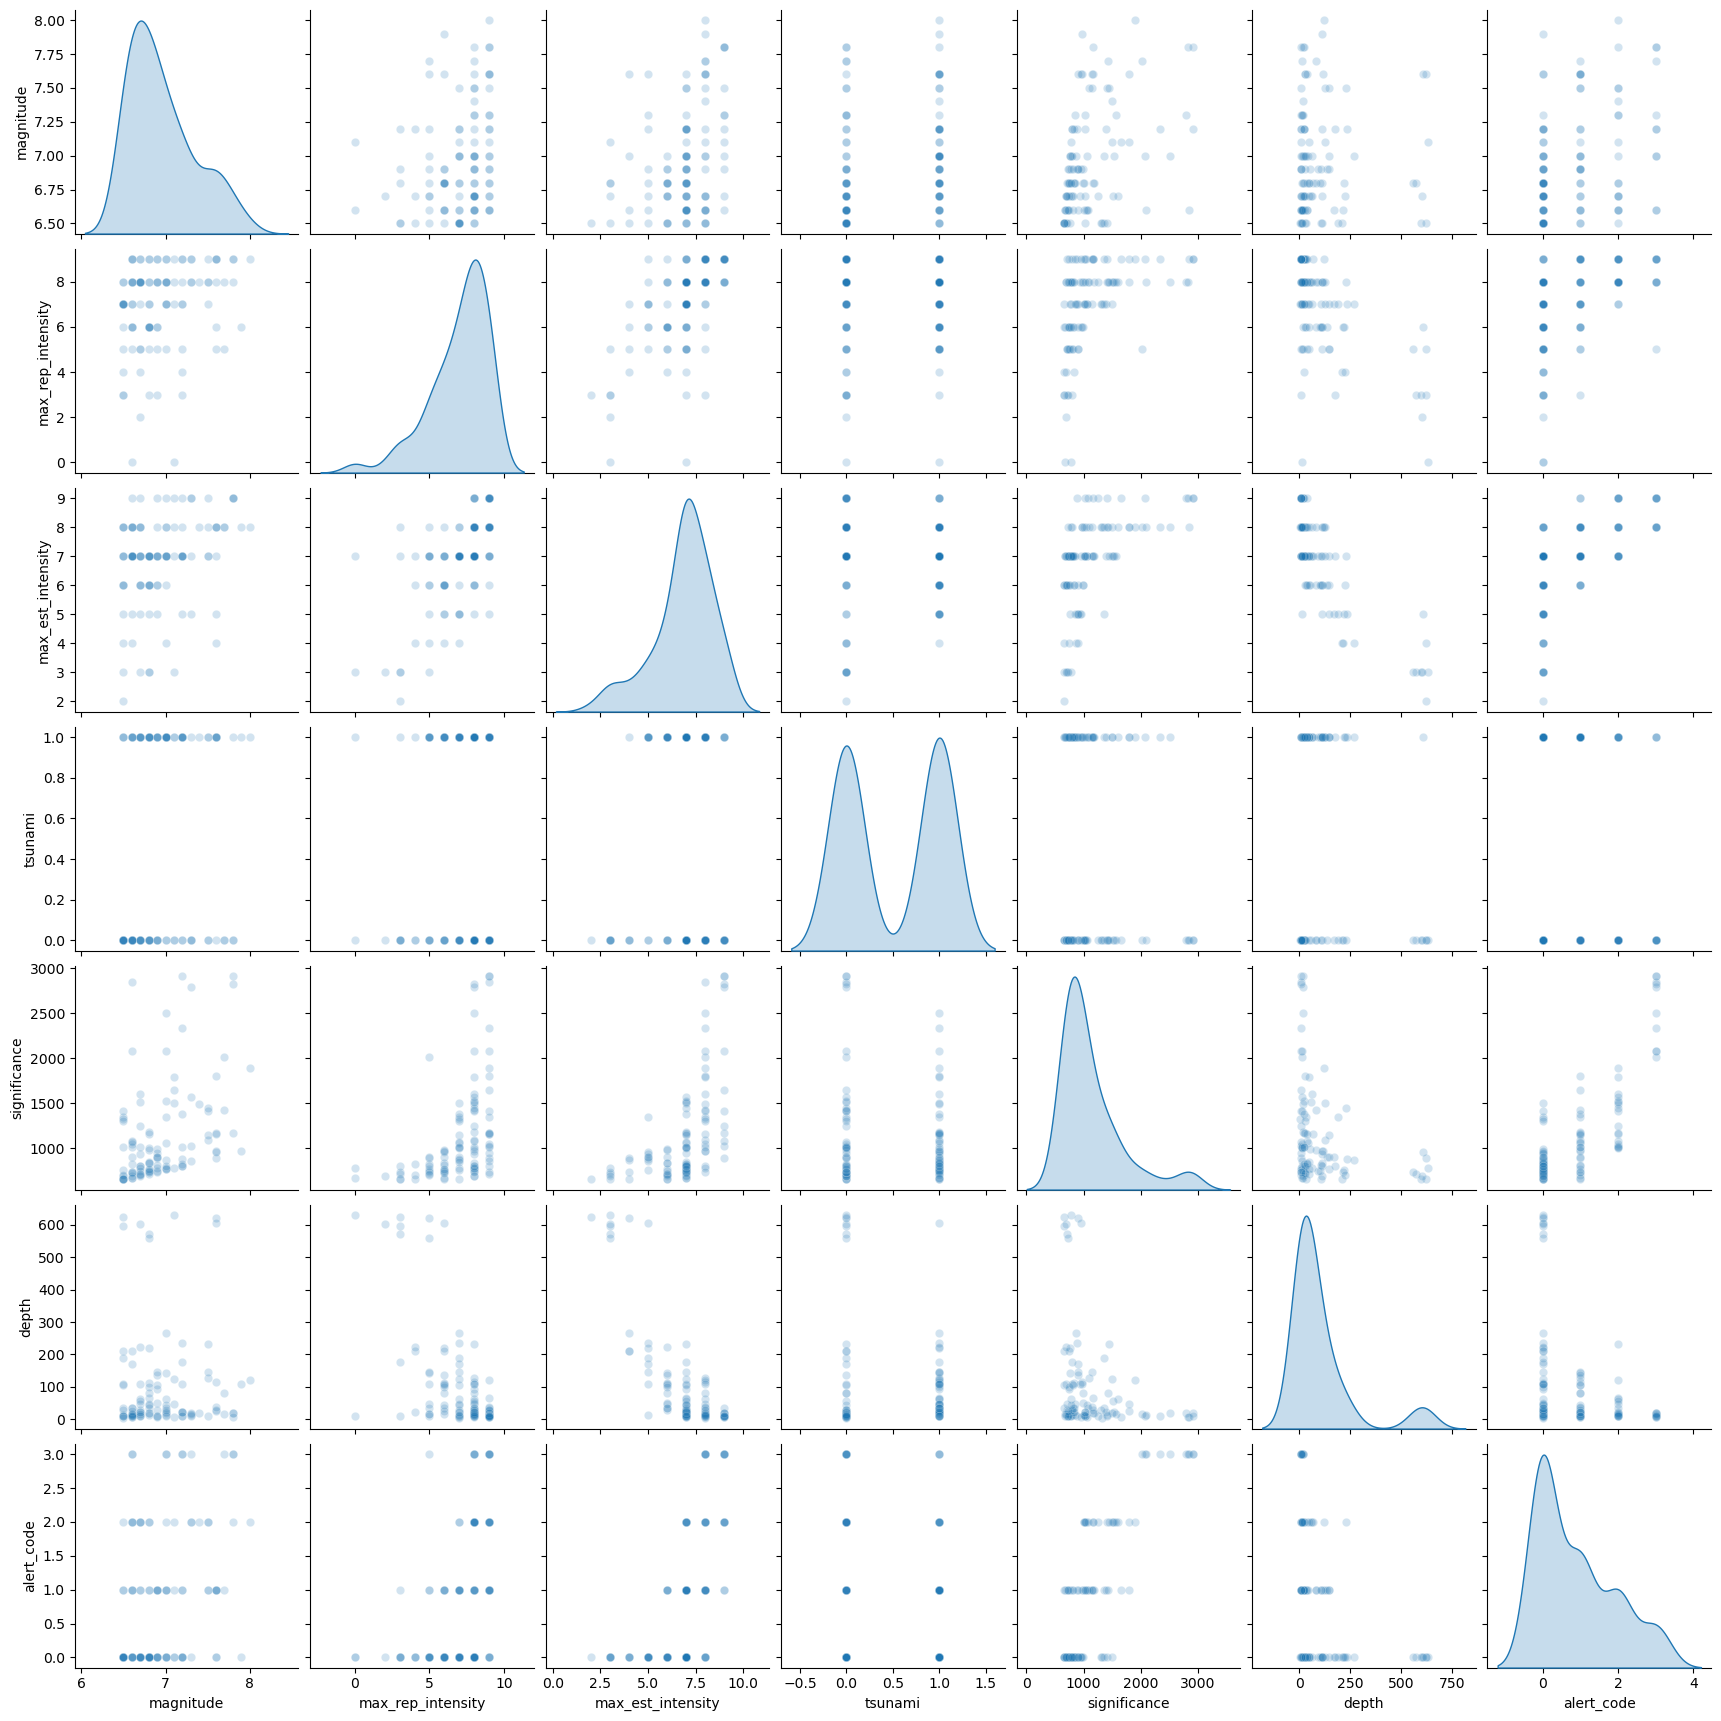

In [212]:

sns.pairplot(new_eq_data, diag_kind='kde', plot_kws={'alpha': 0.2})

<h2>Looking at the correlation between magnitude and alerts:</h2>

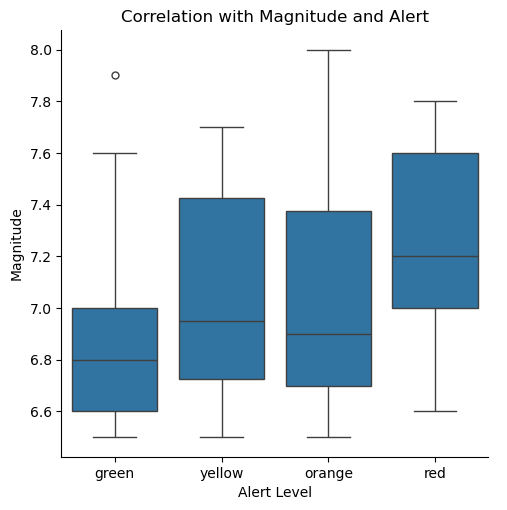

In [231]:
# Box plot of magnitudes and alerts
sns.catplot(x='alert_level', y='magnitude',data=new_eq_data, kind='box')
plt.title('Correlation with Magnitude and Alert')
plt.xlabel('Alert Level')
plt.ylabel('Magnitude')
plt.show()

<h2>Looking at the how significance plays a part in the alert levels, and if tsunamis effect alert level:</h2>

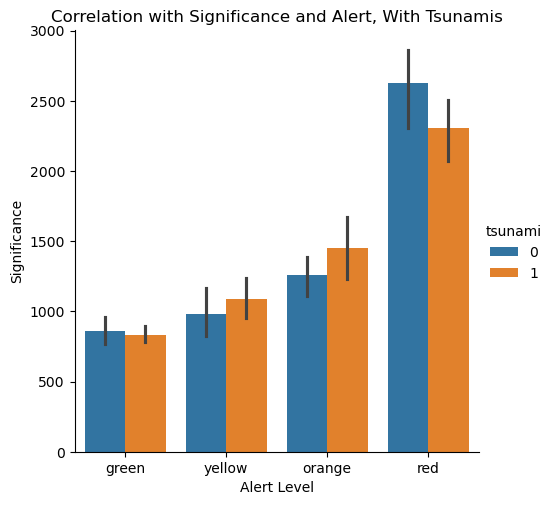

In [229]:
sns.catplot(x='alert_level', y='significance',data=new_eq_data, kind='bar', hue='tsunami', legend=True)
plt.title('Correlation with Significance and Alert, With Tsunamis')
plt.xlabel('Alert Level')
plt.ylabel('Significance')
plt.show()

<h2>Looking to see if depth play a part in the alert levels:</h2>

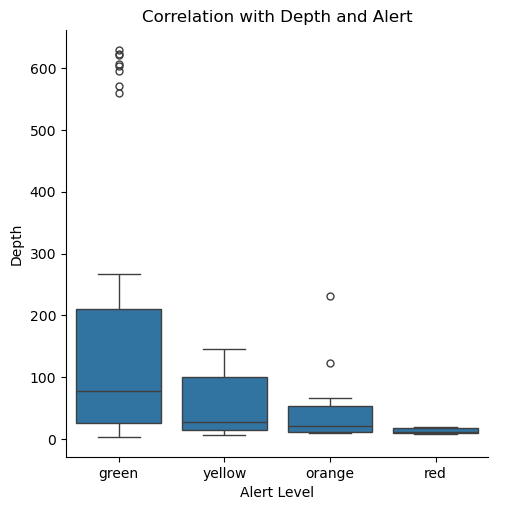

In [227]:
sns.catplot(x='alert_level', y='depth',data=new_eq_data, kind='box')
plt.title('Correlation with Depth and Alert')
plt.xlabel('Alert Level')
plt.ylabel('Depth')
plt.show()

<h2>Looking to see if Maxiumum Represented intensity a part in the alert levels:</h2>

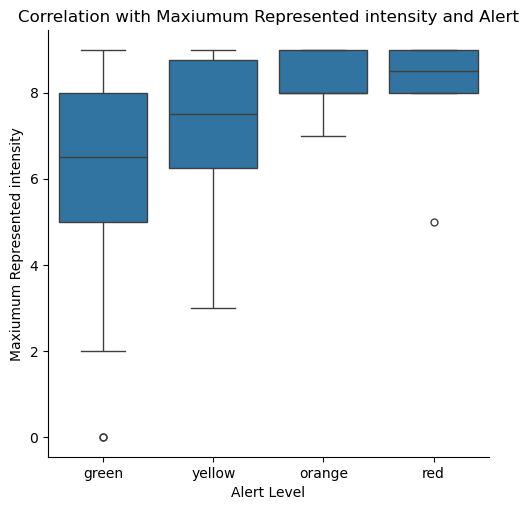

In [223]:
sns.catplot(x='alert_level', y='max_rep_intensity',data=new_eq_data, kind='box')
plt.title('Correlation with Maxiumum Represented intensity and Alert')
plt.xlabel('Alert Level')
plt.ylabel('Maxiumum Represented intensity')
plt.show()

<h2>Looking to see if Maxiumum Estimated intensity a part in the alert levels:</h2>

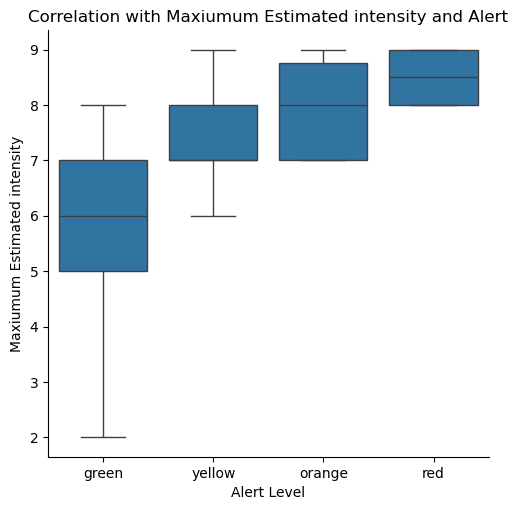

In [225]:
sns.catplot(x='alert_level', y='max_est_intensity',data=new_eq_data, kind='box')
plt.title('Correlation with Maxiumum Estimated intensity and Alert')
plt.xlabel('Alert Level')
plt.ylabel('Maxiumum Estimated intensity')
plt.show()

<h2>Conclusion:</h2>
<body>
<p>This dataset shows that there is a correlation between tsunamis and their alert color. It also signifies that there is a correlation between each of the factors. Looking at Pearson's correlation coefficient, we can see that tsunamis and their significance have the greatest effect on the alerts.</p>
</body>
<h2>Sources:</h2>
<p>https://www.kaggle.com/datasets/warcoder/earthquake-dataset/data?select=earthquake_1995-2023.csv</p>